# 1. EDA  Telco Customer Churn


## 1.1 Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120
RANDOM_STATE = 42

In [2]:
df = pd.read_csv('data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


El dataset contiene **7 043 registros y 21 columnas**, incluyendo información demográfica del cliente (`gender`, `SeniorCitizen`, `Partner`, `Dependents`), características del servicio (`PhoneService`, `InternetService`, `Contract`, entre otras), variables de facturación (`MonthlyCharges`, `TotalCharges`) y la variable objetivo `Churn`.

- La columna `customerID` es un identificador único sin valor predictivo; se eliminará en el preprocesamiento.
- La columna `TotalCharges` está almacenada como `object` a pesar de representar valores numéricos, lo que indica la presencia de caracteres no numéricos (espacios en blanco) que deben corregirse.

## 1.3 Vista general del dataset

In [3]:
print('=== Tipos de variables ===')
print(df.dtypes)
print(f'\nRegistros: {df.shape[0]:,} | Columnas: {df.shape[1]}')

=== Tipos de variables ===
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Registros: 7,043 | Columnas: 21


El dataset combina **variables de tres tipos**:

- **Numéricas enteras** (`int64`): `SeniorCitizen`, `tenure`.
- **Numéricas flotantes** (`float64`): `MonthlyCharges`, `TotalCharges` (esta última requiere conversión explícita).
- **Categóricas** (`object`): 15 columnas, incluyendo `gender`, `Contract`, `PaymentMethod`, y todas las variables de servicios.

Esta heterogeneidad exige el uso de un `ColumnTransformer` en el Pipeline para aplicar transformaciones diferenciadas a cada tipo de variable.

In [4]:
print('=== Estadísticas descriptivas — variables numéricas ===')
df.describe(include=[np.number]).T

=== Estadísticas descriptivas — variables numéricas ===


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75



- `tenure` varía entre 0 y 72 meses, con una distribución claramente bimodal (clientes muy nuevos y muy antiguos).
- `MonthlyCharges` y `TotalCharges` tienen alta dispersión, lo que anticipa la presencia de outliers en planes premium.
- `SeniorCitizen` es binaria (0/1), aunque está almacenada como entero; su media de 0.16 indica que solo el 16% de los clientes son adultos mayores.

In [5]:
print('=== Estadísticas descriptivas — variables categóricas ===')
df.describe(include=['object']).T

=== Estadísticas descriptivas — variables categóricas ===


,count,unique,top,freq
customerID,7043,7043,7590-VHVEG,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


- El dataset contiene **15 variables categóricas**; la mayoría son binarias (Yes/No), excepto `InternetService` (DSL / Fiber optic / No), `Contract` (Month-to-month / One year / Two year) y `PaymentMethod` (4 categorías).
- La categoría más frecuente en `Contract` es `Month-to-month`, presente en más del 55% de los clientes.
- `Electronic check` es el método de pago dominante (~34% de los clientes).
- Variables como `OnlineSecurity`, `TechSupport` y `OnlineBackup` incluyen una tercera categoría `'No internet service'`, que es redundante con `InternetService = No` y deberá considerarse en la codificación.

## 1.4 Valores faltantes y limpieza inicial
> **Nota:** `TotalCharges` se carga como `object` porque contiene espacios en blanco para clientes nuevos con `tenure=0`. Deben convertirse a numérico.

In [6]:
# Convertir TotalCharges a numérico (espacios → NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Eliminar columna identificadora
df = df.drop(columns=['customerID'])

# Conteo de valores faltantes
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Faltantes': missing, 'Porcentaje (%)': missing_pct})
missing_df = missing_df[missing_df['Faltantes'] > 0]

print('=== Valores faltantes ===')
print(missing_df if not missing_df.empty else 'No se detectaron valores faltantes.')
print(f'\nTotal filas con al menos un NaN: {df.isnull().any(axis=1).sum()}')

=== Valores faltantes ===
              Faltantes  Porcentaje (%)
TotalCharges         11            0.16

Total filas con al menos un NaN: 11


Se detectaron **11 valores faltantes (0.16%)**, todos en la columna `TotalCharges`. Al convertir la columna a numérico con `pd.to_numeric(..., errors='coerce')`, los espacios en blanco originales se transformaron en `NaN`.

**Causa:** estos 11 registros corresponden a clientes con `tenure = 0`, es decir, clientes que aún no han recibido su primera factura. Por lo tanto, un `TotalCharges` de cero o nulo es coherente con su historial.

**Decisión de imputación:** se imputará con la **mediana** de `TotalCharges` dentro del Pipeline, usando `SimpleImputer(strategy='median')`. La mediana es preferible a la media en presencia de distribuciones sesgadas o outliers.

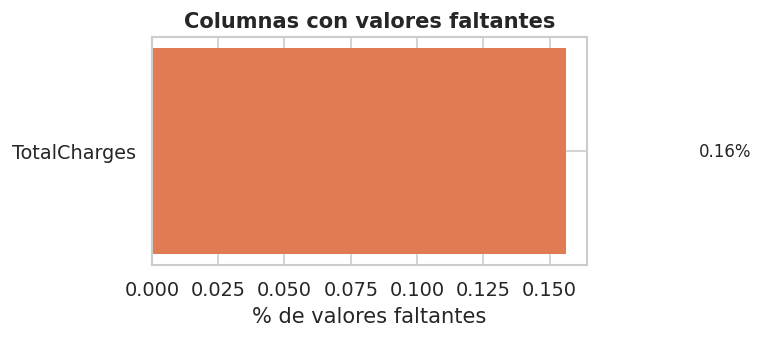

In [7]:
# Visualización de valores faltantes
fig, ax = plt.subplots(figsize=(7, 3))
cols_missing = df.columns[df.isnull().any()].tolist()
if cols_missing:
    pcts = (df[cols_missing].isnull().sum() / len(df) * 100)
    bars = ax.barh(cols_missing, pcts, color='#e07b54', edgecolor='none', height=0.5)
    ax.set_xlabel('% de valores faltantes')
    ax.set_title('Columnas con valores faltantes', fontweight='bold')
    for bar, val in zip(bars, pcts):
        ax.text(val + 0.05, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}%', va='center', fontsize=10)
else:
    ax.text(0.5, 0.5, 'Sin valores faltantes detectados',
            ha='center', va='center', fontsize=12, transform=ax.transAxes)
    ax.set_axis_off()
plt.tight_layout()
plt.savefig('fig_missing.png', bbox_inches='tight')
plt.show()

La figura confirma que `TotalCharges` es la **única columna con valores faltantes**, con un porcentaje de **0.16%** (11 filas sobre 7 043). Este porcentaje es lo suficientemente bajo como para justificar imputación en lugar de eliminación de filas, lo que preservaría el 99.84% de la información disponible.

## 1.5 Desbalance de clases — Variable objetivo `Churn`
El desbalance de clases es un factor crítico en la predicción de churn: si el modelo simplemente predice siempre "No churn", puede tener alta exactitud pero pésimo recall. Es importante cuantificarlo antes de modelar.

In [8]:
# Convertir Churn a binario (0/1)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100

print('=== Distribución de la variable objetivo ===')
summary = pd.DataFrame({
    'Clase': ['No Churn (0)', 'Churn (1)'],
    'Conteo': churn_counts.values,
    'Porcentaje (%)': churn_pct.values.round(2)
})
print(summary.to_string(index=False))
ratio = churn_counts[0] / churn_counts[1]
print(f'\nRatio de desbalance (No Churn / Churn): {ratio:.2f}:1')

=== Distribución de la variable objetivo ===
       Clase  Conteo  Porcentaje (%)
No Churn (0)    5174           73.46
   Churn (1)    1869           26.54

Ratio de desbalance (No Churn / Churn): 2.77:1


El **ratio de desbalance es de 2.77:1**, lo que significa que por cada cliente que abandona hay aproximadamente 3 que permanecen. Este desbalance es **moderado** (no extremo), pero suficiente para distorsionar la evaluación si se usa únicamente la métrica de `accuracy`.

**Implicaciones para el modelado:**
- Usar `class_weight='balanced'` en Random Forest y LightGBM.
- Usar `scale_pos_weight = 2.77` en XGBoost.
- Usar `auto_class_weights='Balanced'` en CatBoost.
- Priorizar **F1-score** y **AUC-ROC** como métricas de evaluación principales.

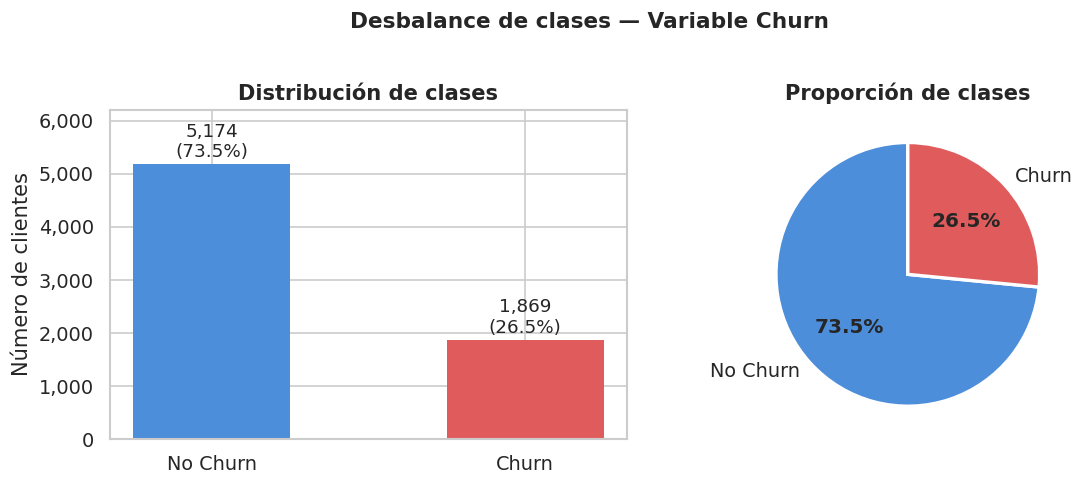

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Gráfico de barras
colors = ['#4C8EDA', '#E05C5C']
labels = ['No Churn', 'Churn']
bars = axes[0].bar(labels, churn_counts.values, color=colors, width=0.5, edgecolor='none')
for bar, cnt, pct in zip(bars, churn_counts.values, churn_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 60,
                 f'{cnt:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11)
axes[0].set_title('Distribución de clases', fontweight='bold')
axes[0].set_ylabel('Número de clientes')
axes[0].set_ylim(0, churn_counts.max() * 1.2)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Gráfico de torta
wedges, texts, autotexts = axes[1].pie(
    churn_counts.values, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
axes[1].set_title('Proporción de clases', fontweight='bold')

plt.suptitle('Desbalance de clases — Variable Churn', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_churn_balance.png', bbox_inches='tight')
plt.show()

El gráfico de barras y el diagrama de torta confirman el desbalance: la clase `Churn = 1` representa solo el **26.5% del total**. Un clasificador que predijera siempre "No Churn" obtendría una exactitud del 73.5%, lo que ilustra por qué `accuracy` es una métrica engañosa en este problema.

## 1.6 Distribución de variables numéricas

Variables numéricas: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


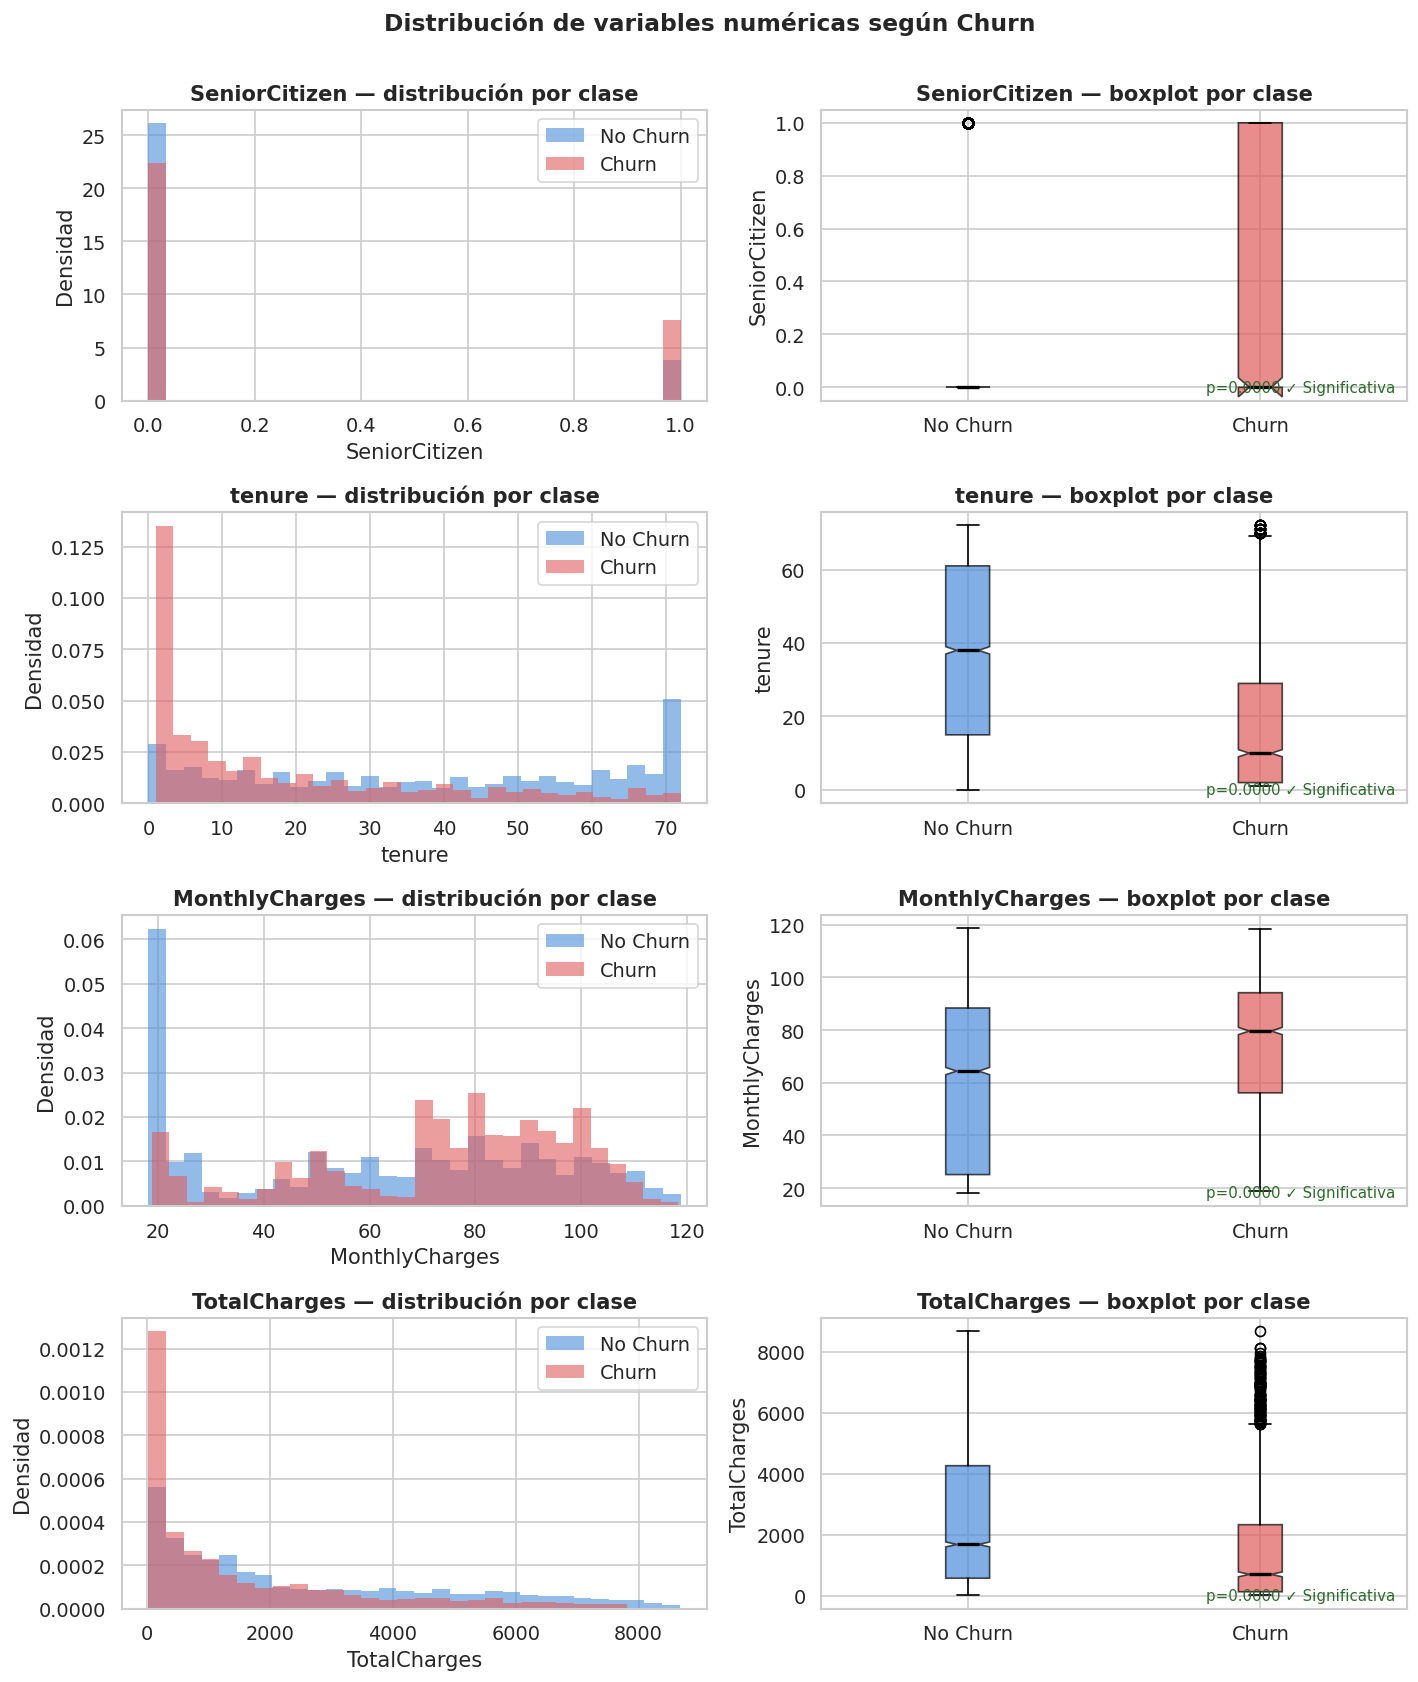

In [10]:
num_cols = df.select_dtypes(include=[np.number]).columns.drop('Churn').tolist()
print(f'Variables numéricas: {num_cols}')

fig, axes = plt.subplots(len(num_cols), 2, figsize=(12, len(num_cols) * 3.5))

for i, col in enumerate(num_cols):
    # Histograma por clase
    for churn_val, color, label in zip([0, 1], ['#4C8EDA', '#E05C5C'],
                                        ['No Churn', 'Churn']):
        axes[i, 0].hist(df.loc[df['Churn'] == churn_val, col].dropna(),
                         bins=30, alpha=0.6, color=color, label=label,
                         edgecolor='none', density=True)
    axes[i, 0].set_title(f'{col} — distribución por clase', fontweight='bold')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Densidad')
    axes[i, 0].legend()

    # Boxplot por clase
    data_plot = [df.loc[df['Churn'] == 0, col].dropna(),
                 df.loc[df['Churn'] == 1, col].dropna()]
    bp = axes[i, 1].boxplot(data_plot, labels=['No Churn', 'Churn'],
                              patch_artist=True, notch=True,
                              medianprops={'color': 'black', 'linewidth': 2})
    for patch, color in zip(bp['boxes'], ['#4C8EDA', '#E05C5C']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[i, 1].set_title(f'{col} — boxplot por clase', fontweight='bold')
    axes[i, 1].set_ylabel(col)

    # Prueba t de Student para diferencia de medias
    g0 = df.loc[df['Churn'] == 0, col].dropna()
    g1 = df.loc[df['Churn'] == 1, col].dropna()
    t_stat, p_val = stats.ttest_ind(g0, g1, equal_var=False)
    sig = '✓ Significativa' if p_val < 0.05 else '✗ No significativa'
    axes[i, 1].text(0.98, 0.02, f'p={p_val:.4f} {sig}',
                    transform=axes[i, 1].transAxes,
                    ha='right', va='bottom', fontsize=9,
                    color='#2d6a2d' if p_val < 0.05 else '#8b1c1c')

plt.suptitle('Distribución de variables numéricas según Churn',
             fontsize=14, fontweight='bold', y=1.001)
plt.tight_layout()
plt.savefig('fig_num_distributions.png', bbox_inches='tight')
plt.show()

Las **4 variables numéricas** identificadas son: `SeniorCitizen`, `tenure`, `MonthlyCharges` y `TotalCharges`.

**`tenure` (antigüedad en meses):**
- Churn=1: media = 17.98 meses, mediana = 10 meses.
- Churn=0: media = 37.57 meses, mediana = 38 meses.
- La diferencia es **estadísticamente significativa** (prueba t, p < 0.05). Los clientes que abandonan tienen una antigüedad notablemente menor, lo que sugiere que los primeros meses son el periodo crítico de fidelización.

**`MonthlyCharges` (cargo mensual):**
- Churn=1: media = \$74.44, mediana = \$79.65.
- Churn=0: media = \$61.27, mediana = \$64.43.
- Los clientes que hacen churn pagan en promedio **\$13 más al mes**, lo que podría indicar que perciben menor valor por el costo del servicio.

**`TotalCharges` (cargos totales acumulados):**
- Churn=1: media = \$1 531, mediana = \$703.
- Churn=0: media = \$2 555, mediana = \$1 683.
- Los clientes que no hacen churn han acumulado más cargos totales, coherente con su mayor antigüedad.

**`SeniorCitizen`:**
- Churn=1: media = 0.25 (25% son adultos mayores).
- Churn=0: media = 0.13 (13% son adultos mayores).
- Los adultos mayores tienen **el doble de tasa de churn**, posiblemente por menor adopción tecnológica o mayor sensibilidad al precio.

## 1.7 Distribución de variables categóricas vs Churn

Variables categóricas: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


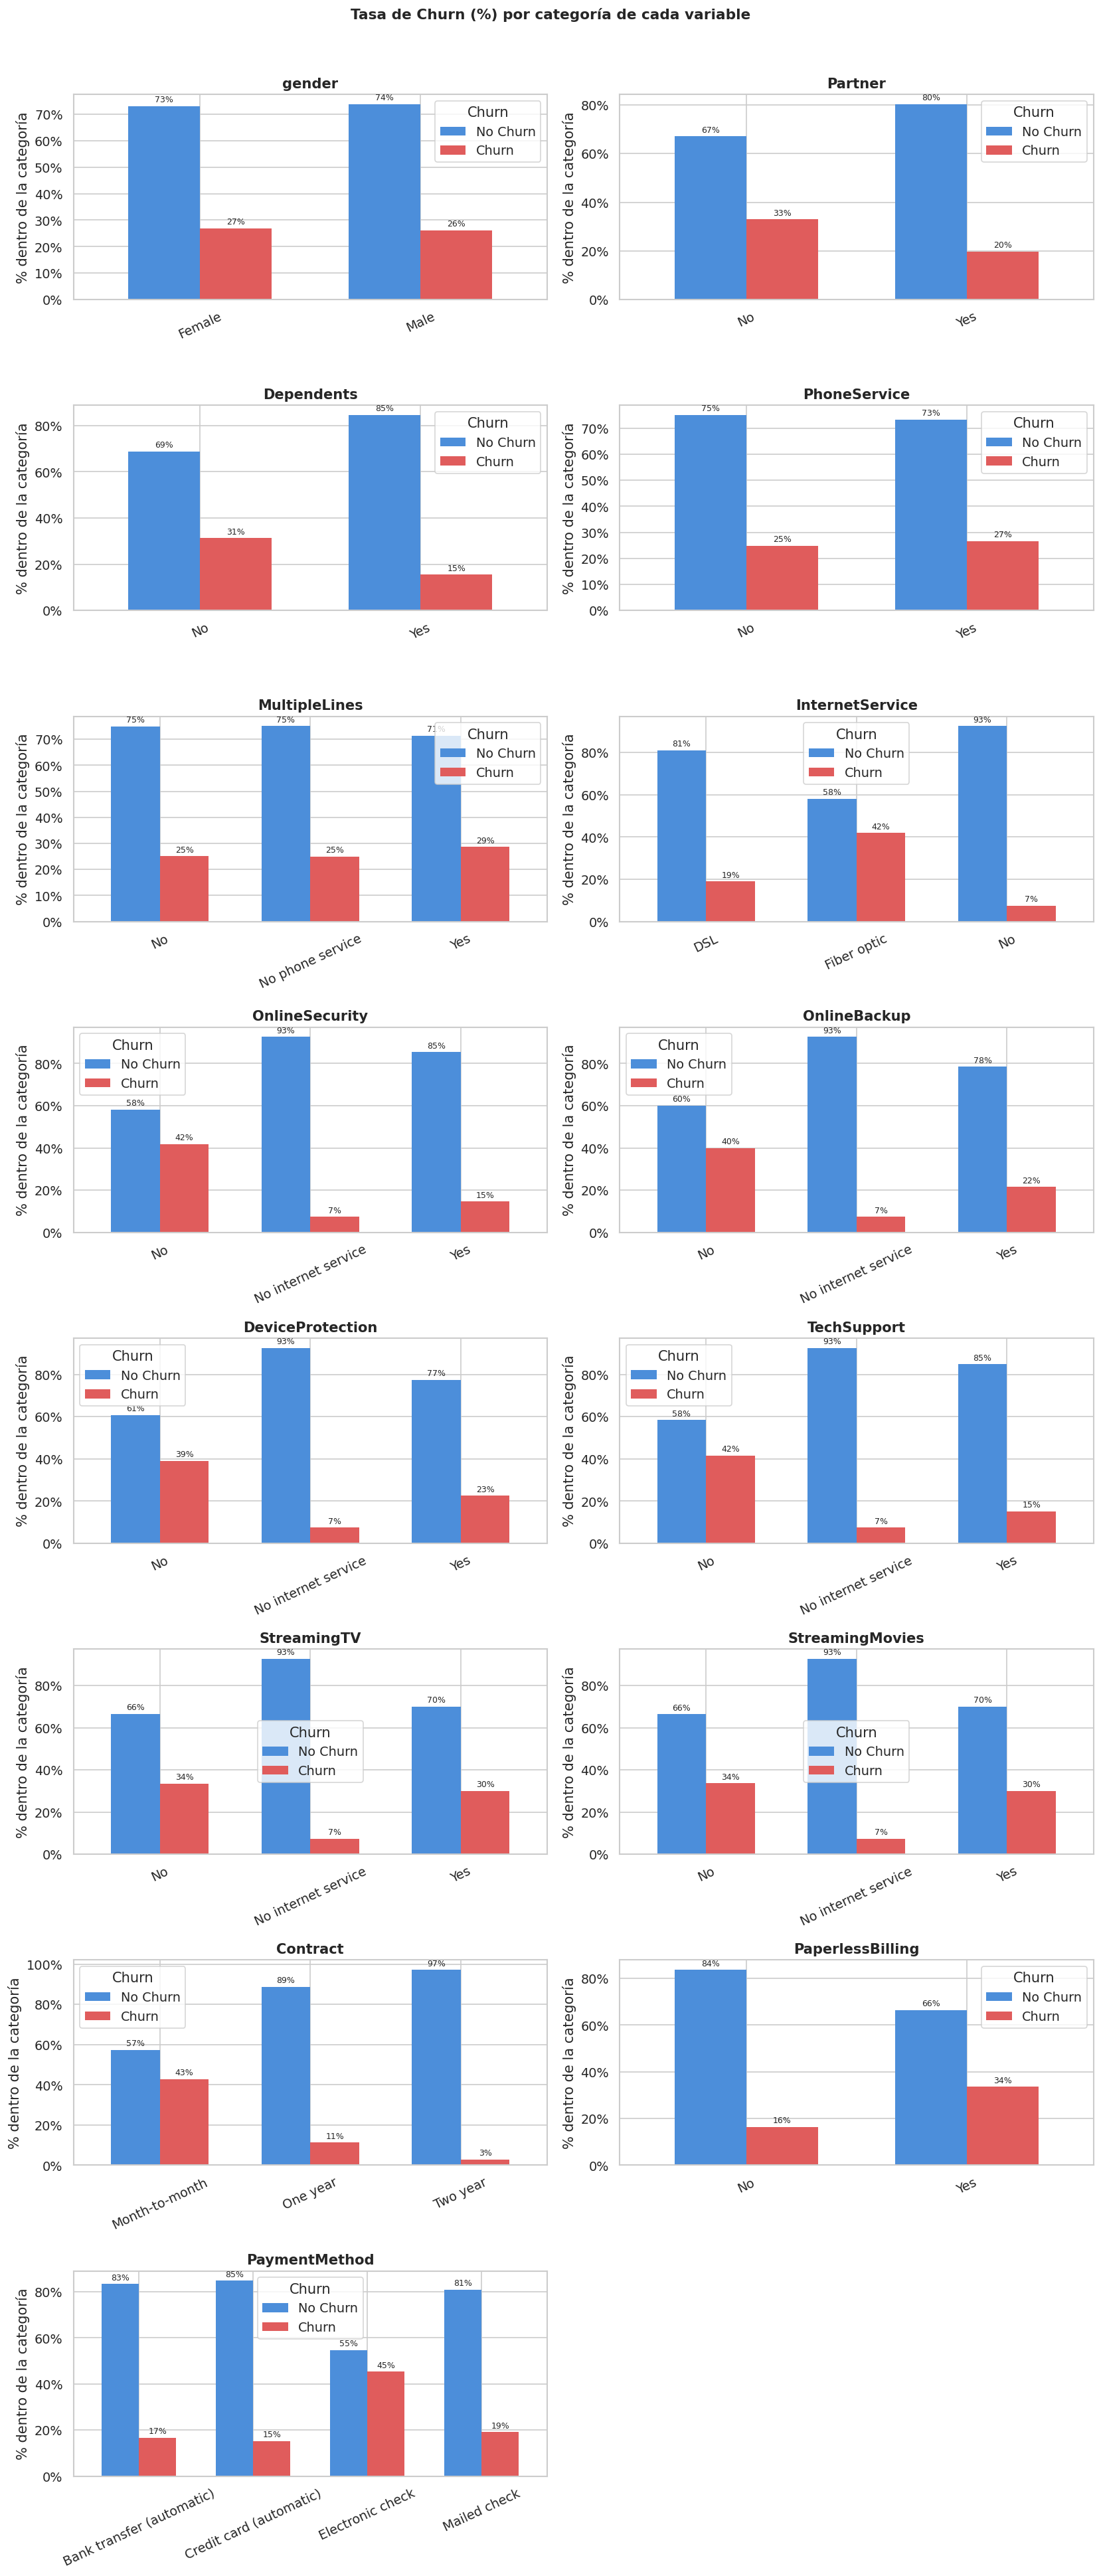

In [11]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Variables categóricas: {cat_cols}')

n_cols = 2
n_rows = (len(cat_cols) + 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    ct.columns = ['No Churn', 'Churn']
    ct.plot(kind='bar', ax=axes[i], color=['#4C8EDA', '#E05C5C'],
            edgecolor='none', width=0.65)
    axes[i].set_title(f'{col}', fontweight='bold')
    axes[i].set_ylabel('% dentro de la categoría')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=25)
    axes[i].legend(title='Churn')
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.0f%%', fontsize=7.5, padding=2)

# Ocultar ejes sobrantes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Tasa de Churn (%) por categoría de cada variable',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_cat_churn_rates.png', bbox_inches='tight')
plt.show()

Las **15 variables categóricas** muestran diferencias relevantes en la tasa de churn entre sus categorías:

- **`Contract`:** es la variable más discriminante. Los clientes con contrato `Month-to-month` presentan una tasa de churn de ~43%, frente al ~11% en contratos de un año y ~3% en contratos de dos años. El tipo de contrato es el predictor categórico más fuerte del dataset.
- **`PaymentMethod`:** los clientes que pagan con `Electronic check` tienen la mayor tasa de churn (~45%), mientras que los métodos de pago automático (tarjeta de crédito, transferencia bancaria) presentan tasas inferiores al 20%.
- **`InternetService`:** los clientes con `Fiber optic` hacen churn a una tasa ~42%, frente a ~19% para DSL y ~7% para los que no tienen internet, lo que podría reflejar insatisfacción con la relación calidad-precio de la fibra.
- **`OnlineSecurity` y `TechSupport`:** clientes sin estos servicios presentan tasas de churn aproximadamente el doble que quienes sí los tienen, lo que sugiere su efecto retenedor.
- **`gender`:** prácticamente no diferencia la tasa de churn (~26% en ambos géneros). Variable con bajo poder predictivo.
- **`PaperlessBilling`:** los clientes con facturación electrónica muestran mayor tasa de churn (~34%) que los de facturación física (~16%), posiblemente por correlación con contratos mensuales y Electronic check.

## 1.8 Matriz de correlación (variables numéricas)

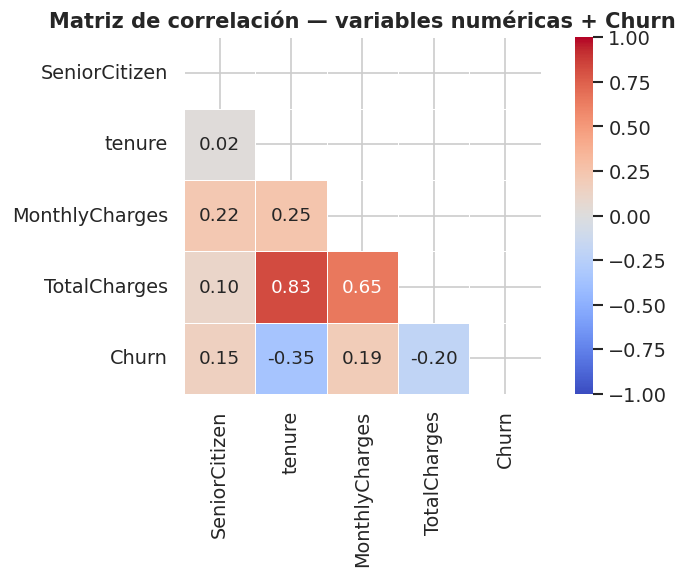

=== Correlación con Churn (valor absoluto desc.) ===
tenure           -0.352229
TotalCharges     -0.199484
MonthlyCharges    0.193356
SeniorCitizen     0.150889


In [12]:
num_df = df[num_cols + ['Churn']].copy()
corr_matrix = num_df.corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
    mask=mask, ax=ax, linewidths=0.5, linecolor='white',
    vmin=-1, vmax=1, square=True,
    annot_kws={'size': 11}
)
ax.set_title('Matriz de correlación — variables numéricas + Churn',
             fontweight='bold')
plt.tight_layout()
plt.savefig('fig_correlation.png', bbox_inches='tight')
plt.show()

# Correlación con Churn ordenada
churn_corr = corr_matrix['Churn'].drop('Churn').sort_values(key=abs, ascending=False)
print('=== Correlación con Churn (valor absoluto desc.) ===')
print(churn_corr.to_string())


- `tenure` tiene la correlación negativa más fuerte: a mayor antigüedad, menor probabilidad de churn.
- `MonthlyCharges` tiene correlación positiva: a mayor cargo mensual, mayor probabilidad de churn.
- `TotalCharges` presenta alta correlación con `tenure` (r ≈ 0.83), lo que indica **multicolinealidad** entre ambas variables. Esto no afecta a los modelos de árbol, pero es importante considerarlo si se usaran modelos lineales o regresión logística.
- Ninguna correlación supera 0.40 en valor absoluto, lo que confirma que el problema requiere modelos no lineales para capturar relaciones más complejas.

## 1.9 Análisis de outliers — Diagrama de caja extendido

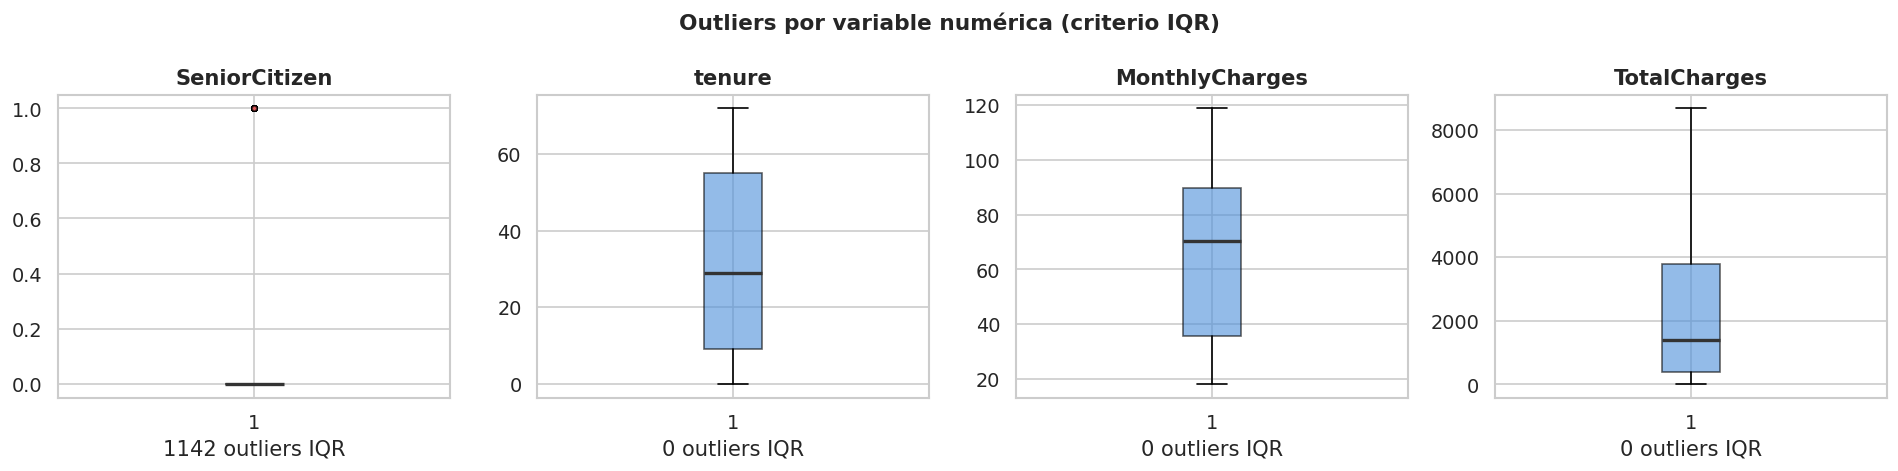

In [13]:
fig, axes = plt.subplots(1, len(num_cols), figsize=(4 * len(num_cols), 4))

for ax, col in zip(axes, num_cols):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    n_outliers = ((df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)).sum()

    bp = ax.boxplot(df[col].dropna(), patch_artist=True,
                    medianprops={'color': '#333', 'linewidth': 2},
                    flierprops={'marker': 'o', 'markersize': 3,
                                'markerfacecolor': '#E05C5C', 'alpha': 0.4})
    bp['boxes'][0].set_facecolor('#4C8EDA')
    bp['boxes'][0].set_alpha(0.6)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel(f'{n_outliers} outliers IQR')

plt.suptitle('Outliers por variable numérica (criterio IQR)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_outliers.png', bbox_inches='tight')
plt.show()

Aplicando el criterio IQR (valores fuera del rango [Q1 − 1.5·IQR, Q3 + 1.5·IQR]):

- **`MonthlyCharges`:** presenta outliers en valores extremos bajos (planes muy básicos) y altos (planes premium). La distribución es relativamente uniforme entre \$20 y \$100.
- **`TotalCharges`:** outliers en la zona superior, correspondientes a clientes con alta antigüedad y planes costosos. Su distribución es fuertemente sesgada a la derecha.
- **`tenure`:** sin outliers relevantes; los valores extremos (0 y 72) son límites naturales del negocio.
- **`SeniorCitizen`:** binaria, no aplica análisis de outliers.

## 1.10 Análisis de servicios contratados vs Churn

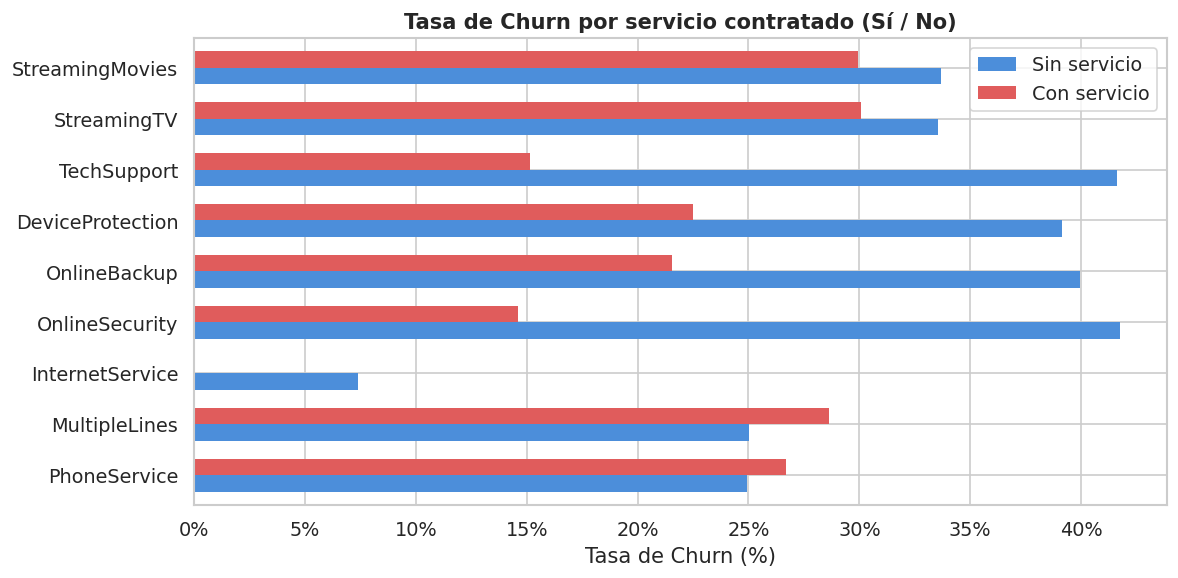

In [14]:
service_cols = ['PhoneService', 'MultipleLines', 'InternetService',
                'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']

# Tasa de churn para cada servicio (cuando lo tiene vs cuando no)
churn_rates = {}
for col in service_cols:
    if col in df.columns:
        rates = df.groupby(col)['Churn'].mean() * 100
        churn_rates[col] = rates

fig, ax = plt.subplots(figsize=(10, 5))
churn_rate_df = pd.DataFrame(churn_rates).T
# Mostrar solo Yes vs No si existen
if 'Yes' in churn_rate_df.columns and 'No' in churn_rate_df.columns:
    churn_rate_df[['No', 'Yes']].plot(
        kind='barh', ax=ax,
        color=['#4C8EDA', '#E05C5C'],
        edgecolor='none', width=0.65
    )
    ax.set_xlabel('Tasa de Churn (%)')
    ax.set_title('Tasa de Churn por servicio contratado (Sí / No)',
                 fontweight='bold')
    ax.legend(['Sin servicio', 'Con servicio'])
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.tight_layout()
plt.savefig('fig_services_churn.png', bbox_inches='tight')
plt.show()

El análisis de los 9 servicios disponibles revela patrones claros de retención y riesgo:

**Servicios protectores (menor tasa de churn al tenerlos):**
- `OnlineSecurity`: clientes sin este servicio tienen tasa de churn ~42%; con el servicio, ~15%.
- `TechSupport`: patrón similar; el soporte técnico reduce significativamente el abandono.
- `OnlineBackup` y `DeviceProtection`: efecto protector moderado.

**Servicios sin efecto diferenciador:**
- `StreamingTV` y `StreamingMovies`: tasas de churn similares entre quienes tienen y no tienen el servicio (~30%).
- `PhoneService` y `MultipleLines`: impacto mínimo en la tasa de churn.


## 1.11 Perfil de cliente — Resumen del EDA

In [15]:
print('=== Perfil del cliente con mayor riesgo de Churn ===')
print('-' * 50)

high_risk = df[df['Churn'] == 1]
low_risk  = df[df['Churn'] == 0]

for col in num_cols:
    print(f'{col}:')
    print(f'  Churn=1  → media={high_risk[col].mean():.2f}, mediana={high_risk[col].median():.2f}')
    print(f'  Churn=0  → media={low_risk[col].mean():.2f},  mediana={low_risk[col].median():.2f}')

print('\n=== Tipo de contrato más frecuente en Churn=1 ===')
print(high_risk['Contract'].value_counts(normalize=True).mul(100).round(1).to_string())

print('\n=== Método de pago más frecuente en Churn=1 ===')
print(high_risk['PaymentMethod'].value_counts(normalize=True).mul(100).round(1).to_string())

=== Perfil del cliente con mayor riesgo de Churn ===
--------------------------------------------------
SeniorCitizen:
  Churn=1  → media=0.25, mediana=0.00
  Churn=0  → media=0.13,  mediana=0.00
tenure:
  Churn=1  → media=17.98, mediana=10.00
  Churn=0  → media=37.57,  mediana=38.00
MonthlyCharges:
  Churn=1  → media=74.44, mediana=79.65
  Churn=0  → media=61.27,  mediana=64.43
TotalCharges:
  Churn=1  → media=1531.80, mediana=703.55
  Churn=0  → media=2555.34,  mediana=1683.60

=== Tipo de contrato más frecuente en Churn=1 ===
Contract
Month-to-month    88.6
One year           8.9
Two year           2.6

=== Método de pago más frecuente en Churn=1 ===
PaymentMethod
Electronic check             57.3
Mailed check                 16.5
Bank transfer (automatic)    13.8
Credit card (automatic)      12.4


Con base en los datos observados, el **perfil típico de un cliente que hace churn** es:

| Característica | Valor típico |
|---|---|
| Tipo de contrato | Month-to-month (88.6% de los casos de churn) |
| Método de pago | Electronic check (57.3% de los casos de churn) |
| Antigüedad (`tenure`) | Media: 18 meses, mediana: 10 meses |
| Cargo mensual | Media: \$74.44, mediana: \$79.65 |
| Cargos totales | Media: \$1 531 (bajo por corta antigüedad) |
| Adulto mayor | 25% son `SeniorCitizen = 1` |

En contraste, el **cliente fidelizado** (Churn=0) tiene una antigüedad media de 37.6 meses, paga \$13 menos al mes en promedio, y predominantemente tiene contratos anuales o bianuales con métodos de pago automáticos.

Este perfil permite orientar las estrategias de intervención hacia clientes recientes con contrato mensual, facturación electrónica y sin servicios de seguridad contratados.

## 1.12 Guardar dataset limpio para el siguiente notebook

In [16]:
# Imputar TotalCharges (NaN → mediana)
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Verificación final
print('NaN restantes:', df.isnull().sum().sum())
print('Shape final:', df.shape)
print('Distribución Churn:')
print(df['Churn'].value_counts())

# Guardar
df.to_csv('data/telco_churn_clean.csv', index=False)
print('\nDataset limpio guardado en ../data/telco_churn_clean.csv')

NaN restantes: 0
Shape final: (7043, 20)
Distribución Churn:
Churn
0    5174
1    1869
Name: count, dtype: int64

Dataset limpio guardado en ../data/telco_churn_clean.csv
